In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [9]:
df = pd.read_csv('/content/drive/MyDrive/colab/mlpr/dataset.csv')

In [4]:
display(df.columns)

Index(['timestamp', 'pm25_ugm3', 'pm10_ugm3', 'no_ugm3', 'no2_ugm3', 'nox_ppb',
       'nh3_ugm3', 'so2_ugm3', 'co_mgm3', 'ozone_ugm3', 'at_c', 'rh_pct',
       'ws_ms', 'wd_deg', 'rf_mm', 'tot_rf_mm', 'sr_wm2', 'state', 'city',
       'station', 'station_id', 'latitude', 'longitude', 'era5_sw_down_wm2',
       'era5_dewpoint_k', 'era5_pressure_pa', 'era5_temp_k',
       'era5_cloud_cover', 'era5_precip_m', 'era5_u10_ms', 'era5_v10_ms',
       'era5_temp_c', 'era5_dewpoint_c', 'era5_pressure_hpa', 'era5_precip_mm',
       'era5_wind_speed_ms', 'era5_wind_dir_deg', 'era5_vpd_kpa',
       'era5_rh_pct', 'solar_altitude_deg', 'solar_zenith_deg', 'cos_zenith'],
      dtype='object')

In [10]:
#df.drop(columns=['latitude', 'longitude', 'station_id', 'station', 'state', 'city'],  inplace=True)
from sklearn.preprocessing import LabelEncoder


target_encoders = {}

for col in ['station_id', 'station', 'state', 'city']:
    if col in df.columns:
        target_encoders[col] = df.groupby(col)['sr_wm2'].mean().to_dict()

# Step 2: Apply encoding to entire dataset
for col in ['station_id', 'station', 'state', 'city']:
    if col in df.columns:
        df[f'{col}_encoded'] = df[col].map(target_encoders[col])
        # Fill any missing values (unseen categories) with global mean
        df[f'{col}_encoded'].fillna(df['sr_wm2'].mean(), inplace=True)


float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('float32')

df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.info())

/tmp/ipykernel_1839/567494980.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[f'{col}_encoded'].fillna(df['sr_wm2'].mean(), inplace=True)
/tmp/ipykernel_1839/567494980.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2549291 entries, 0 to 2549290
Data columns (total 46 columns):
 #   Column              Dtype         
---  ------              -----         
 0   timestamp           datetime64[ns]
 1   pm25_ugm3           float32       
 2   pm10_ugm3           float32       
 3   no_ugm3             float32       
 4   no2_ugm3            float32       
 5   nox_ppb             float32       
 6   nh3_ugm3            float32       
 7   so2_ugm3            float32       
 8   co_mgm3             float32       
 9   ozone_ugm3          float32       
 10  at_c                float32       
 11  rh_pct              float32       
 12  ws_ms               float32       
 13  wd_deg              float32       
 14  rf_mm               float32       
 15  tot_rf_mm           float32       
 16  sr_wm2              float32       
 17  state               object        
 18  city                object        
 19  station             object        
 20  st

In [6]:
# Check for missing values
missing_data = df.isnull().sum()
print("Missing values per column:\n", missing_data[missing_data > 0])

# Summary statistics of numerical columns
display(df.describe())

# Check temporal coverage
print(f"Data ranges from {df['timestamp'].min()} to {df['timestamp'].max()}")

Missing values per column:
 Series([], dtype: int64)


,timestamp,pm25_ugm3,pm10_ugm3,no_ugm3,no2_ugm3,nox_ppb,nh3_ugm3,so2_ugm3,co_mgm3,ozone_ugm3,...,era5_dewpoint_c,era5_pressure_hpa,era5_precip_mm,era5_wind_speed_ms,era5_wind_dir_deg,era5_vpd_kpa,era5_rh_pct,solar_altitude_deg,solar_zenith_deg,cos_zenith
count,2549291,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,...,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06,2.549291e+06
mean,2024-07-12 02:14:47.580429824,4.188275e+01,9.484842e+01,8.817250e+00,1.769503e+01,1.928344e+01,2.083845e+01,1.228526e+01,6.984427e-01,3.972440e+01,...,1.911414e+01,9.776608e+02,1.703613e-01,2.627517e+00,1.973055e+02,1.674933e+00,6.202049e+01,3.747908e+01,5.252092e+01,5.630006e-01
min,2023-01-01 07:00:00,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,...,-1.970654e+01,8.029435e+02,0.000000e+00,1.467543e-03,0.000000e+00,0.000000e+00,1.990431e+00,7.010949e-06,1.012989e-01,1.223641e-07
25%,2023-10-23 07:00:00,1.866667e+01,4.688000e+01,1.925000e+00,7.260000e+00,6.837500e+00,8.510000e+00,4.160000e+00,3.400000e-01,1.584000e+01,...,1.427704e+01,9.627969e+02,0.000000e+00,1.509653e+00,1.002838e+02,6.774687e-01,4.573385e+01,1.918246e+01,3.640986e+01,3.285776e-01
50%,2024-07-10 10:00:00,3.109000e+01,7.575000e+01,3.975000e+00,1.309000e+01,1.252500e+01,1.568000e+01,8.000000e+00,5.550000e-01,3.077000e+01,...,2.018604e+01,9.819400e+02,0.000000e+00,2.366550e+00,2.269820e+02,1.317940e+00,6.479462e+01,3.727040e+01,5.272960e+01,6.055774e-01
75%,2025-04-04 18:00:00,5.232000e+01,1.209900e+02,8.290000e+00,2.237500e+01,2.240000e+01,2.670250e+01,1.486667e+01,8.600000e-01,5.447750e+01,...,2.459488e+01,9.972018e+02,4.100800e-02,3.493125e+00,2.837038e+02,2.246976e+00,7.939188e+01,5.359014e+01,7.081754e+01,8.047917e-01
max,2025-12-31 18:00:00,1.000000e+03,1.000000e+03,5.000000e+02,4.960200e+02,4.999400e+02,4.934200e+02,2.000000e+02,2.979750e+01,4.956700e+02,...,3.128574e+01,1.022125e+03,3.618717e+01,1.434470e+01,3.599995e+02,1.138882e+01,1.000000e+02,8.989870e+01,8.999999e+01,9.999985e-01
std,NaN,4.055224e+01,7.454008e+01,2.438113e+01,1.805892e+01,2.903597e+01,2.016551e+01,1.450794e+01,6.230684e-01,3.255500e+01,...,6.177508e+00,3.231558e+01,6.860947e-01,1.499462e+00,1.018352e+02,1.347383e+00,2.090220e+01,2.206181e+01,2.206203e+01,2.856436e-01


Data ranges from 2023-01-01 07:00:00 to 2025-12-31 18:00:00


In [12]:
num_cols = X_train.select_dtypes(include=["int64", "float32", "float64"]).columns

print("Constant/low-variance columns:")
print(X_train[num_cols].nunique().sort_values().head(20))

print("\nMissing values:")
print(X_train[num_cols].isna().sum().sort_values(ascending=False).head(20))

print("\nInfinite values present:")
print(np.isinf(X_train[num_cols].to_numpy()).any())

Constant/low-variance columns:
tot_rf_mm             2195
rf_mm                 9580
era5_precip_mm       14935
era5_precip_m        14935
co_mgm3              15299
era5_cloud_cover     32769
no_ugm3              61886
so2_ugm3             63439
no2_ugm3             64007
ws_ms                66550
nox_ppb              72757
nh3_ugm3             73072
ozone_ugm3           86818
pm25_ugm3           100068
rh_pct              135879
pm10_ugm3           145187
at_c                200046
wd_deg              211837
era5_v10_ms         476136
era5_temp_c         490937
dtype: int64

Missing values:
pm25_ugm3           0
pm10_ugm3           0
no_ugm3             0
no2_ugm3            0
nox_ppb             0
nh3_ugm3            0
so2_ugm3            0
co_mgm3             0
ozone_ugm3          0
at_c                0
rh_pct              0
ws_ms               0
wd_deg              0
rf_mm               0
tot_rf_mm           0
era5_dewpoint_k     0
era5_pressure_pa    0
era5_temp_k         0
era

In [11]:
from sklearn.preprocessing import PowerTransformer

# Make sure rows are in chronological order
df = df.sort_values("timestamp").reset_index(drop=True)

# Feature engineering
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour

# cols_to_drop = ["sr_wm2", "era5_sw_down_wm2", "timestamp"]
# X = df.drop(columns=cols_to_drop)
# y = df["sr_wm2"]

# # Time-based split: first 80% train, last 20% test
# split_idx = int(len(df) * 0.8)
# X_train = X.iloc[:split_idx].copy()
# X_test = X.iloc[split_idx:].copy()
# y_train = y.iloc[:split_idx].copy()
# y_test = y.iloc[split_idx:].copy()

# Step 3: Keep latitude/longitude as numeric, drop original categorical columns
cols_to_drop = ["sr_wm2", "era5_sw_down_wm2", "timestamp", 
                'station_id', 'station', 'state', 'city']  # Original categorical cols
X = df.drop(columns=cols_to_drop)
y = df["sr_wm2"]

# Your existing train/test split remains the same
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Encoded features:")
print(X_train.columns.tolist())
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Random split: 80% train, 20% test
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# Power transform only numeric features, fit on train only
# num_cols = X_train.select_dtypes(include=["int64", "float32", "float64"]).columns

# low_var_cols = [c for c in num_cols if X_train[c].nunique(dropna=False) > 1]
# pt = PowerTransformer(method="yeo-johnson", standardize=True)
# X_train[low_var_cols] = pt.fit_transform(X_train[low_var_cols])
# X_test[low_var_cols] = pt.transform(X_test[low_var_cols])

# train_data = lgb.Dataset(X_train, label=y_train)
# test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

Encoded features:
['pm25_ugm3', 'pm10_ugm3', 'no_ugm3', 'no2_ugm3', 'nox_ppb', 'nh3_ugm3', 'so2_ugm3', 'co_mgm3', 'ozone_ugm3', 'at_c', 'rh_pct', 'ws_ms', 'wd_deg', 'rf_mm', 'tot_rf_mm', 'latitude', 'longitude', 'era5_dewpoint_k', 'era5_pressure_pa', 'era5_temp_k', 'era5_cloud_cover', 'era5_precip_m', 'era5_u10_ms', 'era5_v10_ms', 'era5_temp_c', 'era5_dewpoint_c', 'era5_pressure_hpa', 'era5_precip_mm', 'era5_wind_speed_ms', 'era5_wind_dir_deg', 'era5_vpd_kpa', 'era5_rh_pct', 'solar_altitude_deg', 'solar_zenith_deg', 'cos_zenith', 'station_id_encoded', 'station_encoded', 'state_encoded', 'city_encoded', 'year', 'month', 'day', 'hour']

X_train shape: (2039432, 43)
X_test shape: (509859, 43)


In [12]:
from cuml.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 78.9426498413086
R2: 0.5750075578689575


In [13]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',     # Enalbe GPU acceleration
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2:", r2_score(y_test, y_pred_xgb))
# old: .53


XGBoost Results:
MAE: 71.01224517822266
R2: 0.6494076251983643


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 9646
[LightGBM] [Info] Number of data points in the train set: 2039432, number of used features: 43
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 39 dense feature groups (77.80 MB) transferred to GPU in 0.099677 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 210.234281

--- Model Performance ---
RMSE: 118.56 W/m²
MAE:  65.73 W/m²
R² Score: 0.6756

Top 10 Most Important Features:


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

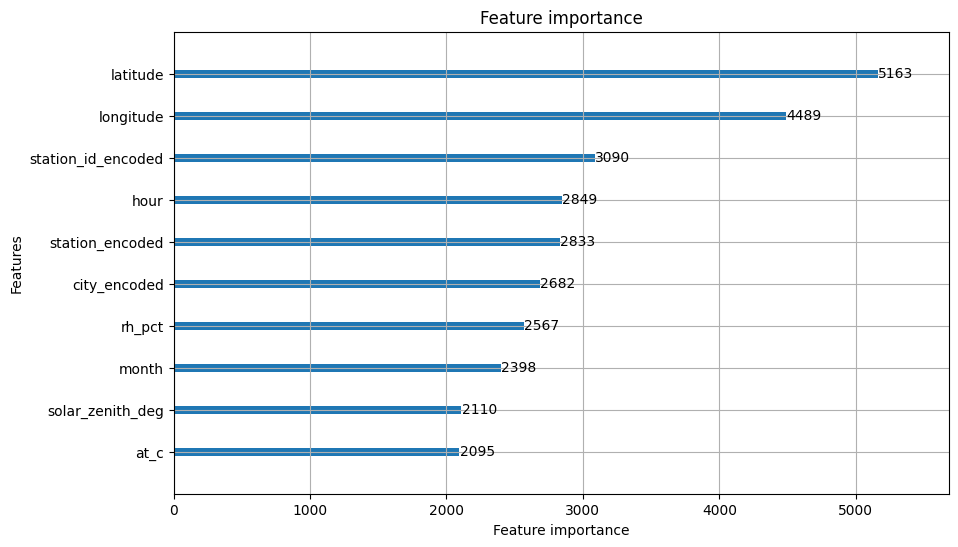

In [14]:
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'device': 'gpu',           # Enable GPU
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.8,
}

model = lgb.train(params, train_data, num_boost_round=1000, valid_sets=[train_data, test_data])

# 7. Predictions & Evaluation
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"RMSE: {rmse:.2f} W/m²")
print(f"MAE:  {mae:.2f} W/m²")
print(f"R² Score: {r2:.4f}")

# 8. Feature Importance
print("\nTop 10 Most Important Features:")
lgb.plot_importance(model, max_num_features=10, figsize=(10, 6))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
50986/50986 - 166s - 3ms/step - loss: 40862.6289 - mae: 141.3643 - val_loss: 33120.2773 - val_mae: 128.4962
Epoch 2/50
50986/50986 - 160s - 3ms/step - loss: 33384.4062 - mae: 130.4195 - val_loss: 31692.3574 - val_mae: 130.0716
Epoch 3/50
50986/50986 - 202s - 4ms/step - loss: 31925.9062 - mae: 126.4139 - val_loss: 31231.7812 - val_mae: 120.0265
Epoch 4/50
50986/50986 - 160s - 3ms/step - loss: 31400.8242 - mae: 124.7877 - val_loss: 32001.0566 - val_mae: 120.1219
Epoch 5/50
50986/50986 - 161s - 3ms/step - loss: 31142.3438 - mae: 123.9958 - val_loss: 32068.5547 - val_mae: 118.7731
Epoch 6/50
50986/50986 - 158s - 3ms/step - loss: 31002.7637 - mae: 123.5818 - val_loss: 30034.5059 - val_mae: 119.7904
Epoch 7/50
50986/50986 - 160s - 3ms/step - loss: 30867.1621 - mae: 123.1454 - val_loss: 30395.7480 - val_mae: 118.0417
Epoch 8/50
50986/50986 - 161s - 3ms/step - loss: 30765.4785 - mae: 122.8589 - val_loss: 31071.1191 - val_mae: 130.7808
Epoch 9/50
50986/50986 - 162s - 3ms/step - loss:

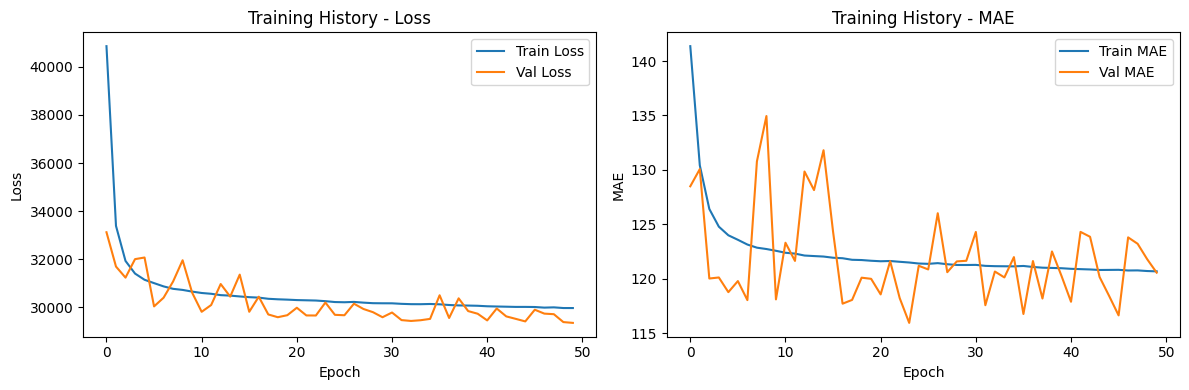

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

# Create a shallow neural network
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=2
)

# Test the model
y_pred_nn = model.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mae = mean_absolute_error(y_test, y_pred_nn)
r2 = r2_score(y_test, y_pred_nn)

print("\n--- Neural Network Results ---")
print(f"RMSE: {rmse:.2f} W/m²")
print(f"MAE:  {mae:.2f} W/m²")
print(f"R² Score: {r2:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training History - Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Training History - MAE')
plt.tight_layout()
plt.show()

Calculating SHAP values...


Generating Force Plot...
Generating Summary Plot...


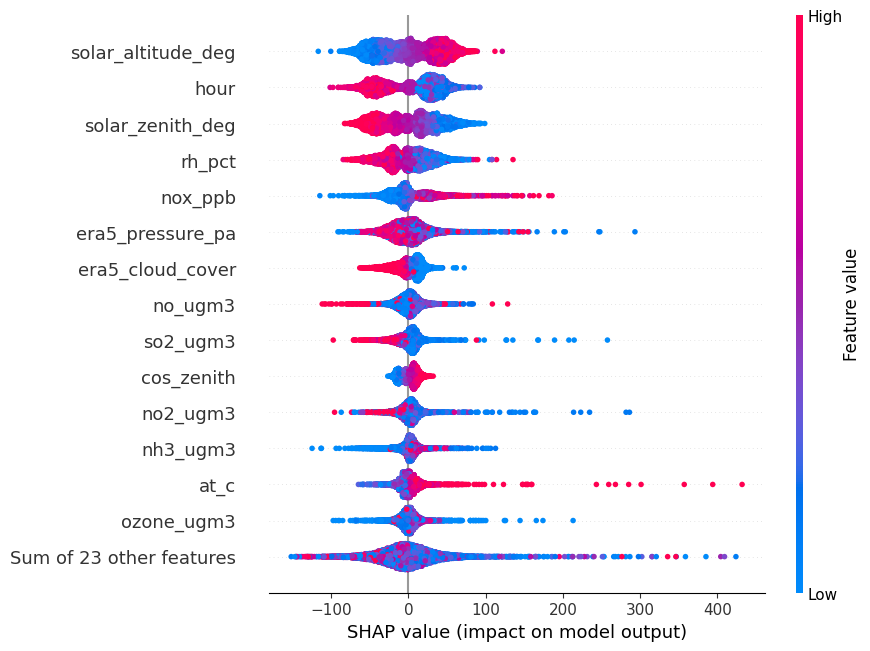

Generating Dependence Plot...


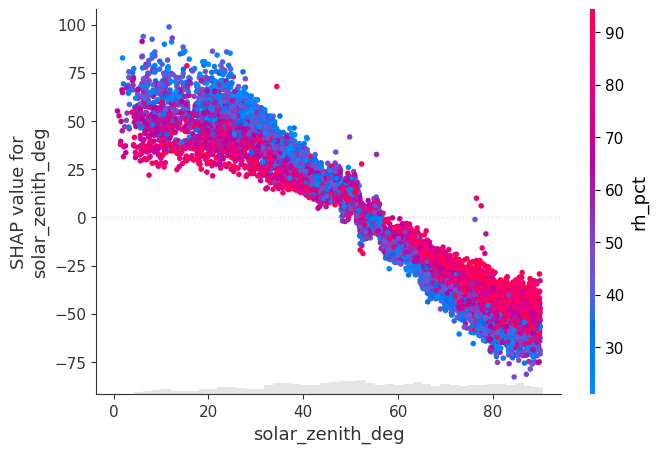

In [ ]:
import shap

X_shap = X_test.sample(n=10000, random_state=42)

explainer = shap.TreeExplainer(model)

print("Calculating SHAP values...")
shap_values = explainer(X_shap)

# PLOT 1: FORCE PLOT (Single Prediction)
shap.initjs()

print("Generating Force Plot...")
shap.plots.force(shap_values[0])


# PLOT 2: SUMMARY PLOT (Overall Importance)
print("Generating Summary Plot...")
# A beeswarm plot shows both the rank of importance AND the directional impact
shap.plots.beeswarm(shap_values, max_display=15)

# PLOT 3: DEPENDENCE PLOT (Feature Effect)
print("Generating Dependence Plot...")
shap.plots.scatter(shap_values[:, "solar_zenith_deg"], color=shap_values)

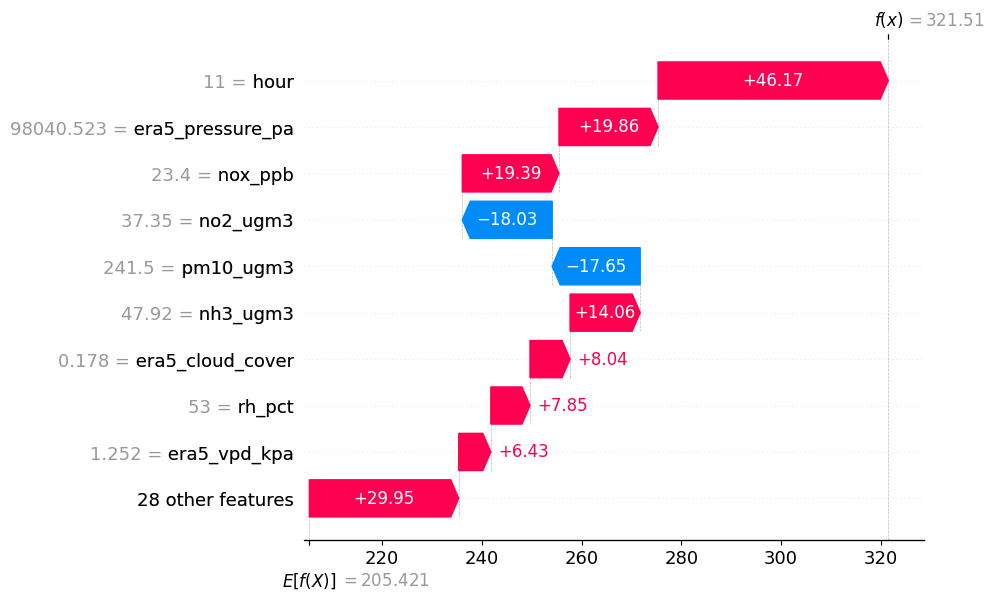

In [19]:
shap.plots.waterfall(shap_values[0])